In [1]:
import pandas as pd
import numpy as np
import re
import string
import warnings

import matplotlib.pyplot as plt
import matplotlib.transforms as transforms
import seaborn as sns

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist, squareform
from langdetect import detect, DetectorFactory

warnings.filterwarnings('ignore')
DetectorFactory.seed = 0 # for consistency

In [2]:
df = pd.read_csv('data/amazon_bestsellers_reviews.csv')
df.dtypes # helpful_votes should be int, date should be datetime64
df.head()

,department,product_index,product_name,product_url,reviewer,rating,date,verified,title,body,helpful_votes,variant,image_count
0,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,Sridhar Mani,5,"Reviewed in the United States on March 17, 2026",Verified Purchase,Best-in-Class Quality and Sound,These Apple EarPods with USB-C are truly best ...,28 people found this helpful,Size: One SizeStyle: USB-C,0
1,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,A.S,5,"Reviewed in the United States on April 11, 2026",Verified Purchase,Great Sound and Comfort,"I bought these for my son, who prefers traditi...",8 people found this helpful,Size: One SizeStyle: USB-C,0
2,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,Amazon_Customer,5,"Reviewed in the United States on April 10, 2026",Verified Purchase,"The $9 Audiophile Secret: Small Dongle, Big Pr...",Let’s be honest: nobody actually wants to live...,7 people found this helpful,Size: One SizeStyle: USB-C,0
3,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,K,5,"Reviewed in the United States on March 17, 2026",Verified Purchase,better than overhead headphones,I honestly love these headphones so much. I ac...,23 people found this helpful,Size: One SizeStyle: USB-C,0
4,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,Low,5,"Reviewed in the United States on April 25, 2026",Verified Purchase,Worth the extra money. They're the best ones I...,"Best you can buy. I have 4 usbc ear buds, thes...",NaN,Size: One SizeStyle: USB-C,0


In [3]:
# Split date into date and location, parse date
pattern = r'Reviewed in (.+?) on (.+)'
df[['location', 'date']] = df['date'].str.extract(pattern)
df['date'] = pd.to_datetime(df['date'])
df.head()

,department,product_index,product_name,product_url,reviewer,rating,date,verified,title,body,helpful_votes,variant,image_count,location
0,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,Sridhar Mani,5,2026-03-17,Verified Purchase,Best-in-Class Quality and Sound,These Apple EarPods with USB-C are truly best ...,28 people found this helpful,Size: One SizeStyle: USB-C,0,the United States
1,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,A.S,5,2026-04-11,Verified Purchase,Great Sound and Comfort,"I bought these for my son, who prefers traditi...",8 people found this helpful,Size: One SizeStyle: USB-C,0,the United States
2,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,Amazon_Customer,5,2026-04-10,Verified Purchase,"The $9 Audiophile Secret: Small Dongle, Big Pr...",Let’s be honest: nobody actually wants to live...,7 people found this helpful,Size: One SizeStyle: USB-C,0,the United States
3,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,K,5,2026-03-17,Verified Purchase,better than overhead headphones,I honestly love these headphones so much. I ac...,23 people found this helpful,Size: One SizeStyle: USB-C,0,the United States
4,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,Low,5,2026-04-25,Verified Purchase,Worth the extra money. They're the best ones I...,"Best you can buy. I have 4 usbc ear buds, thes...",NaN,Size: One SizeStyle: USB-C,0,the United States


In [4]:
# Clean helpful_votes and create target column
pattern = r'(One|\d+)'
df['helpful_votes'] = df['helpful_votes'].str.extract(pattern)[0]
df['helpful_votes'] = df['helpful_votes'].replace('One', 1)
df['helpful_votes'] = pd.to_numeric(df['helpful_votes'], errors='coerce').fillna(0).astype(int)
df['is_helpful'] = (df['helpful_votes'] > 0).astype(int) # Assign 1 or 0
df.head()

,department,product_index,product_name,product_url,reviewer,rating,date,verified,title,body,helpful_votes,variant,image_count,location,is_helpful
0,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,Sridhar Mani,5,2026-03-17,Verified Purchase,Best-in-Class Quality and Sound,These Apple EarPods with USB-C are truly best ...,28,Size: One SizeStyle: USB-C,0,the United States,1
1,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,A.S,5,2026-04-11,Verified Purchase,Great Sound and Comfort,"I bought these for my son, who prefers traditi...",8,Size: One SizeStyle: USB-C,0,the United States,1
2,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,Amazon_Customer,5,2026-04-10,Verified Purchase,"The $9 Audiophile Secret: Small Dongle, Big Pr...",Let’s be honest: nobody actually wants to live...,7,Size: One SizeStyle: USB-C,0,the United States,1
3,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,K,5,2026-03-17,Verified Purchase,better than overhead headphones,I honestly love these headphones so much. I ac...,23,Size: One SizeStyle: USB-C,0,the United States,1
4,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,Low,5,2026-04-25,Verified Purchase,Worth the extra money. They're the best ones I...,"Best you can buy. I have 4 usbc ear buds, thes...",0,Size: One SizeStyle: USB-C,0,the United States,0


In [5]:
# Text Preprocessing (Title + Body)

# Remove emojis and non-ascii characters
df['title'] = df['title'].str.encode('ascii', 'ignore').str.decode('ascii')
df['body'] = df['body'].str.encode('ascii', 'ignore').str.decode('ascii')

# Filter non-english reviews
def is_english(text):
    try:
        return detect(str(text)) == 'en'
    except:
        return False

df = df[df['body'].apply(is_english)].copy()


# Preparing Text for LSA
df['text_for_lsa'] = df['title'].fillna('') + ' ' + df['body'].fillna('')
df['text_for_lsa'] = df['text_for_lsa'].str.lower()
df['text_for_lsa'] = df['text_for_lsa'].str.replace(f"[{re.escape(string.punctuation)}]", " ", regex=True)
df['text_for_lsa'] = df['text_for_lsa'].str.replace(r'\d+', '', regex=True)

# Removing Stopwords
def remove_stopwords(text):
    words = [word for word in text.split() if word not in ENGLISH_STOP_WORDS]
    return ' '.join(words)

df['text_for_lsa'] = df['text_for_lsa'].apply(remove_stopwords)
df['text_for_lsa'] = df['text_for_lsa'].str.strip().str.replace(r'\s+', ' ', regex=True)

df.head()

,department,product_index,product_name,product_url,reviewer,rating,date,verified,title,body,helpful_votes,variant,image_count,location,is_helpful,text_for_lsa
0,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,Sridhar Mani,5,2026-03-17,Verified Purchase,Best-in-Class Quality and Sound,These Apple EarPods with USB-C are truly best ...,28,Size: One SizeStyle: USB-C,0,the United States,1,best class quality sound apple earpods usb c t...
1,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,A.S,5,2026-04-11,Verified Purchase,Great Sound and Comfort,"I bought these for my son, who prefers traditi...",8,Size: One SizeStyle: USB-C,0,the United States,1,great sound comfort bought son prefers traditi...
2,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,Amazon_Customer,5,2026-04-10,Verified Purchase,"The $9 Audiophile Secret: Small Dongle, Big Pr...",Lets be honest: nobody actually wants to live ...,7,Size: One SizeStyle: USB-C,0,the United States,1,audiophile secret small dongle big practicalit...
3,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,K,5,2026-03-17,Verified Purchase,better than overhead headphones,I honestly love these headphones so much. I ac...,23,Size: One SizeStyle: USB-C,0,the United States,1,better overhead headphones honestly love headp...
4,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,Low,5,2026-04-25,Verified Purchase,Worth the extra money. They're the best ones I...,"Best you can buy. I have 4 usbc ear buds, thes...",0,Size: One SizeStyle: USB-C,0,the United States,0,worth extra money best ones best buy usbc ear ...


## Feature Engineering: Encoding Categorical Variables

Before SVD and clustering, all categorical columns are converted to numerical form to ensure
ML compatibility. `helpful_votes` is deliberately excluded from the feature set here (kept
in the DataFrame but **not used as a model feature**) to prevent data leakage into `is_helpful`.

In [6]:
# ── Encode categorical features for ML ──────────────────────────────────────
# 'helpful_votes' is excluded from the feature table to avoid data leakage
# (is_helpful was derived from it), but it REMAINS in df for reference.

# Rating: already numeric (1–5); cast to int for safety
df['rating'] = pd.to_numeric(df['rating'], errors='coerce').fillna(df['rating'].median()).astype(int)

# Date-derived features (year, month, day-of-week)
df['year']        = df['date'].dt.year.astype(int)
df['month']       = df['date'].dt.month.astype(int)
df['day_of_week'] = df['date'].dt.dayofweek.astype(int)

# Location: frequency-encode (encode by count of reviews per location)
loc_freq = df['location'].value_counts()
df['location_freq'] = df['location'].map(loc_freq).fillna(0).astype(int)

# Verified purchase: boolean → int (1/0)
if 'verified_purchase' in df.columns:
    df['verified_purchase'] = df['verified_purchase'].map({True: 1, False: 0, 'True': 1, 'False': 0})
    df['verified_purchase'] = pd.to_numeric(df['verified_purchase'], errors='coerce').fillna(0).astype(int)

# Title / Body length features (text remains; lengths are numeric)
df['title_len'] = df['title'].fillna('').str.len().astype(int)
df['body_len']  = df['body'].fillna('').str.len().astype(int)
df['word_count'] = df['text_for_lsa'].str.split().str.len().fillna(0).astype(int)

print("DataFrame dtypes after encoding:")
print(df.dtypes)
print(f"\nDataFrame shape: {df.shape}")

DataFrame dtypes after encoding:
department                  str
product_index             int64
product_name                str
product_url                 str
reviewer                    str
rating                    int64
date             datetime64[us]
verified                    str
title                       str
body                        str
helpful_votes             int64
variant                     str
image_count               int64
location                    str
is_helpful                int64
text_for_lsa                str
year                      int64
month                     int64
day_of_week               int64
location_freq             int64
title_len                 int64
body_len                  int64
word_count                int64
dtype: object

DataFrame shape: (1517, 23)


## Why SVD Instead of PCA?

| Criterion | SVD (TruncatedSVD) | PCA |
|---|---|---|
| **Input format** | Sparse matrices (TF-IDF) natively | Requires dense matrix |
| **Centering** | Not required — works on raw TF-IDF | Requires zero-mean centering, which destroys sparsity |
| **Memory** | O(k) — only top-k singular vectors | O(n²) covariance matrix |
| **Speed** | Randomised SVD in sklearn is ~10× faster on large text data | Scales poorly |
| **Interpretability** | Singular values directly express "energy" in latent topics (LSA) | Eigenvalues are a derived quantity |
| **Negative values** | Allowed — captures semantic opposition | Same, but direction is less interpretable for text |

**Conclusion:** For sparse, high-dimensional TF-IDF matrices, `TruncatedSVD` is the
mathematically appropriate and computationally efficient choice. PCA would require
densifying the matrix, introducing prohibitive memory costs. This specific use of SVD
on TF-IDF is known as **Latent Semantic Analysis (LSA)**.

In [7]:
# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(token_pattern=r'\w+', min_df=5)
tfidf_matrix = tfidf_vectorizer.fit_transform(df['text_for_lsa'])
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"Sparsity: {1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0]*tfidf_matrix.shape[1]):.4f}")

TF-IDF matrix shape: (1517, 2026)
Sparsity: 0.9839


In [8]:
# 5. LSA (Latent Semantic Analysis) via TruncatedSVD
svd = TruncatedSVD(n_components=100, random_state=42)
lsa_features = svd.fit_transform(tfidf_matrix)
singular_values = svd.singular_values_
variance_explained = svd.explained_variance_ratio_

print(f"Top 10 singular values: {np.round(singular_values[:10], 4)}")
print(f"Top 10 variance ratios: {np.round(variance_explained[:10], 4)}")
print(f"Total variance explained (100 SVs): {variance_explained.sum():.4f}")

Top 10 singular values: [7.6759 4.4491 3.883  3.6878 3.6177 3.3586 3.2673 3.2118 3.1124 3.0536]
Top 10 variance ratios: [0.0038 0.0135 0.0103 0.0093 0.0089 0.0077 0.0073 0.007  0.0066 0.0064]
Total variance explained (100 SVs): 0.3608


In [9]:
"""Utility functions for SVD and LSA notebook""" # UTILS

def plot_singular_values(singular_values, thresh=None):
    """Bar chart of raw singular values."""
    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(1, len(singular_values) + 1)
    bars = ax.bar(x, singular_values, color='steelblue', edgecolor='none', alpha=0.85)

    if thresh is not None:
        ax.axvline(thresh, linestyle='--', lw=2, color='tab:orange', label=f'Threshold SV: {thresh}')
        ax.legend(fontsize=11)

    # Annotate top 10
    for i in range(min(10, len(singular_values))):
        ax.text(x[i], singular_values[i] + singular_values[0]*0.01,
                f'{singular_values[i]:.2f}', ha='center', va='bottom', fontsize=8, color='navy')

    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlabel('Singular Value Index', fontsize=12)
    ax.set_ylabel('Singular Value Magnitude', fontsize=12)
    fig.suptitle('Singular Values of TF-IDF Matrix (LSA)', fontsize=14, weight='bold')
    plt.tight_layout()
    return fig, ax

def plot_variance_cumulative(variance_ratio, tol=0.90):
    """Cumulative variance explained plot (mirrors the energy plot but in variance terms)."""
    cumvar = np.cumsum(variance_ratio)
    thresh = int(np.argmax(cumvar >= tol)) + 1

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(range(0, len(cumvar) + 1), [0] + cumvar.tolist(),
            lw=3, marker='o', markersize=4, color='steelblue', label='Cumulative Variance')
    ax.axvline(thresh, linestyle='-', lw=2.5, color='tab:orange', label=f'90% threshold @ SV {thresh}')
    ax.axhline(tol, linestyle=':', lw=1.5, color='gray')

    trans = transforms.blended_transform_factory(ax.transData, ax.transAxes)
    ax.text(thresh + 1, 0.08, f'SVs needed: {thresh}',
            color='tab:orange', weight='bold', fontsize=11, transform=trans)

    ax.set_xlim(0, len(cumvar))
    ax.set_ylim(0, 1.05)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlabel('Number of SVs', fontsize=12)
    ax.set_ylabel('Cumulative Variance Explained', fontsize=12)
    ax.legend(fontsize=11)
    fig.suptitle('Cumulative Variance Explained vs. Number of SVs', fontsize=14, weight='bold')
    plt.tight_layout()
    return fig, ax, thresh

def plot_variance_per_sv(variance_ratio, n_show=40):
    """Individual variance contribution per singular vector."""
    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(1, n_show + 1)
    ax.bar(x, variance_ratio[:n_show] * 100, color='teal', edgecolor='none', alpha=0.85)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlabel('Singular Vector Index', fontsize=12)
    ax.set_ylabel('Variance Explained (%)', fontsize=12)
    fig.suptitle(f'Individual Variance per Singular Vector (top {n_show})', fontsize=14, weight='bold')
    plt.tight_layout()
    return fig, ax

def plot_scree(singular_values, n_show=40):
    """Scree plot – elbow detection aid."""
    diffs = np.diff(singular_values[:n_show])
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(range(1, n_show + 1), singular_values[:n_show],
                 marker='o', lw=2, color='steelblue')
    axes[0].spines[['top', 'right']].set_visible(False)
    axes[0].set_title('Scree Plot (Singular Values)', fontsize=13, weight='bold')
    axes[0].set_xlabel('SV Index')
    axes[0].set_ylabel('Singular Value')

    axes[1].plot(range(2, n_show + 1), diffs, marker='o', lw=2, color='tomato')
    axes[1].axhline(0, linestyle='--', color='gray', lw=1)
    axes[1].spines[['top', 'right']].set_visible(False)
    axes[1].set_title('First Difference of Singular Values', fontsize=13, weight='bold')
    axes[1].set_xlabel('SV Index')
    axes[1].set_ylabel('Δ Singular Value')
    plt.tight_layout()
    return fig, axes

def plot_energy_ratio(energy_ratio, tol=0.90):
    """Original cumulative energy plot (kept for compatibility)."""
    cumulative = np.cumsum(energy_ratio)
    thresh = int(np.argmax(cumulative >= tol)) + 1

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(range(0, len(cumulative) + 1), [0] + cumulative.tolist(), lw=3, marker='o')
    ax.axvline(thresh, linestyle='-', lw=2.5, color='tab:orange')

    trans = transforms.blended_transform_factory(ax.transData, ax.transAxes)
    ax.text(1.05*thresh, 0.05, f'Number of SVs: {thresh}',
            color='tab:orange', weight='bold', fontsize=12, transform=trans)

    ax.set_ylim(0, 1)
    ax.set_xlim(0, len(cumulative))
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlabel('Number of SVs', fontsize=12)
    ax.set_ylabel('Cumulative Energy Preserved', fontsize=12)
    fig.suptitle('Cumulative Energy Preserved vs Number of SVs', fontsize=14, weight='bold')
    plt.tight_layout()
    return fig, ax, thresh

## Singular Value Analysis

The following four plots examine the singular values from different angles:
1. **Raw singular value magnitudes** – how much signal each latent dimension captures.
2. **Cumulative variance explained** – how quickly variance accumulates; used to pick the truncation threshold.
3. **Per-SV variance contribution** – the individual "weight" of each latent dimension.
4. **Scree plot + first differences** – visual elbow to guide dimensionality selection.

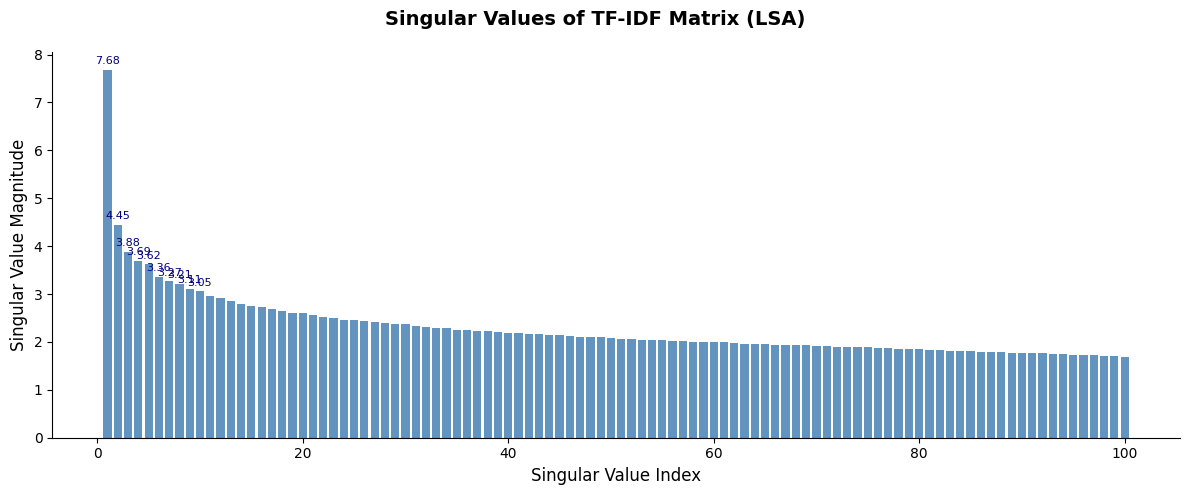


--- Singular Value Insights ---
  Largest SV  : 7.6759
  Smallest SV : 1.6926
  Ratio (σ1/σk): 4.53x
  Top-5 SVs   : [7.6759 4.4491 3.883  3.6878 3.6177]
  Interpretation: A steep drop from σ1 suggests a few dominant latent topics;
  a gradual decay indicates distributed topic structure across reviews.


In [10]:
# ── Graph 1: Raw Singular Values ────────────────────────────────────────────
fig1, ax1 = plot_singular_values(singular_values)
plt.show()

print("\n--- Singular Value Insights ---")
print(f"  Largest SV  : {singular_values[0]:.4f}")
print(f"  Smallest SV : {singular_values[-1]:.4f}")
print(f"  Ratio (σ1/σk): {singular_values[0]/singular_values[-1]:.2f}x")
print(f"  Top-5 SVs   : {np.round(singular_values[:5], 4)}")
print("  Interpretation: A steep drop from σ1 suggests a few dominant latent topics;")
print("  a gradual decay indicates distributed topic structure across reviews.")

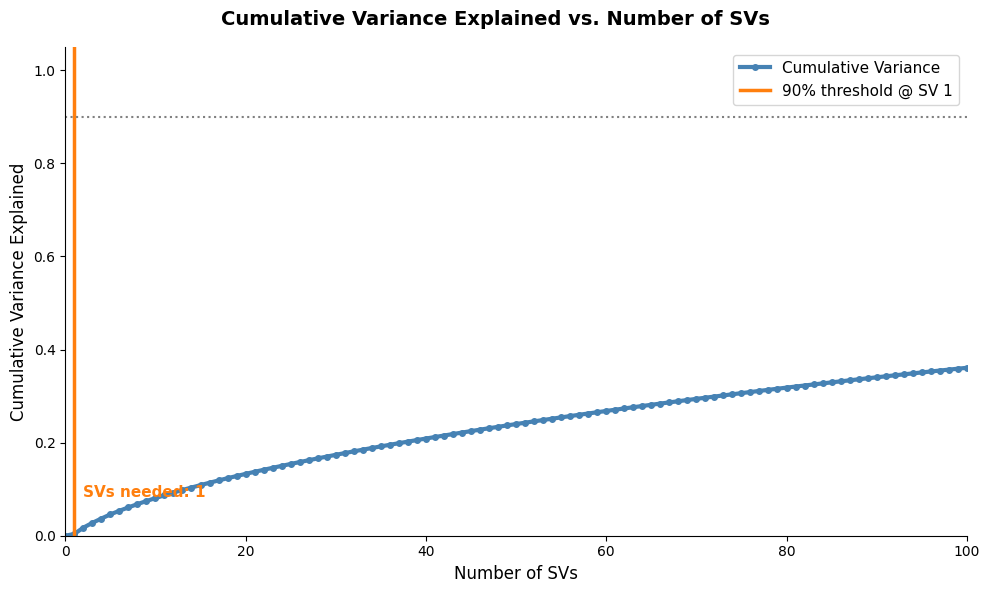


SVs needed to explain 90% variance: 1
Variance explained by first SV     : 0.38%
Variance explained by top-1 SVs : 0.38%


In [11]:
# ── Graph 2: Cumulative Variance Explained (variance, not energy) ────────────
fig2, ax2, thresh = plot_variance_cumulative(variance_explained, tol=0.90)
plt.show()

print(f"\nSVs needed to explain 90% variance: {thresh}")
print(f"Variance explained by first SV     : {variance_explained[0]*100:.2f}%")
print(f"Variance explained by top-{thresh} SVs : {variance_explained[:thresh].sum()*100:.2f}%")

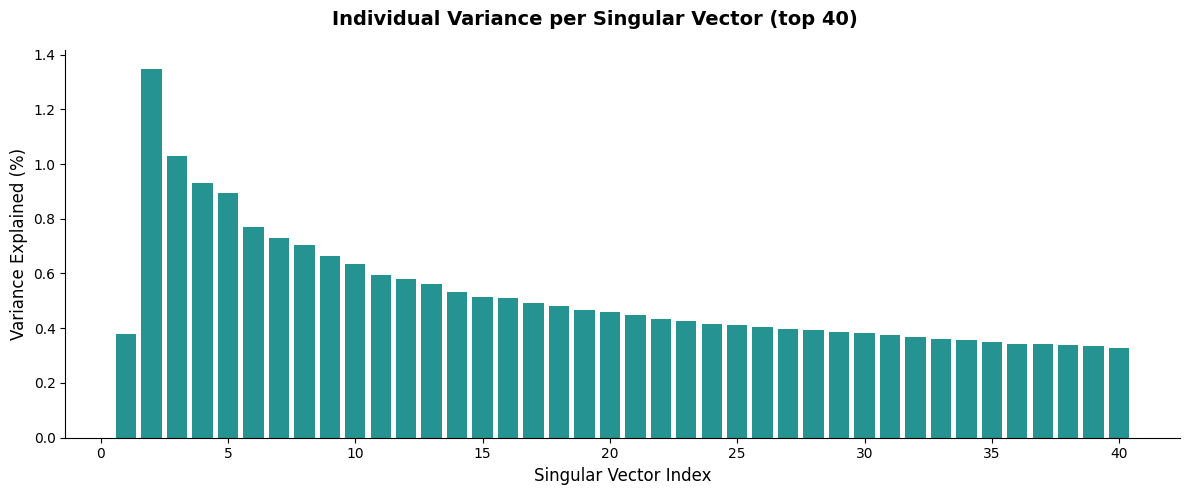

In [12]:
# ── Graph 3: Per-SV Variance ─────────────────────────────────────────────────
fig3, ax3 = plot_variance_per_sv(variance_explained, n_show=40)
plt.show()

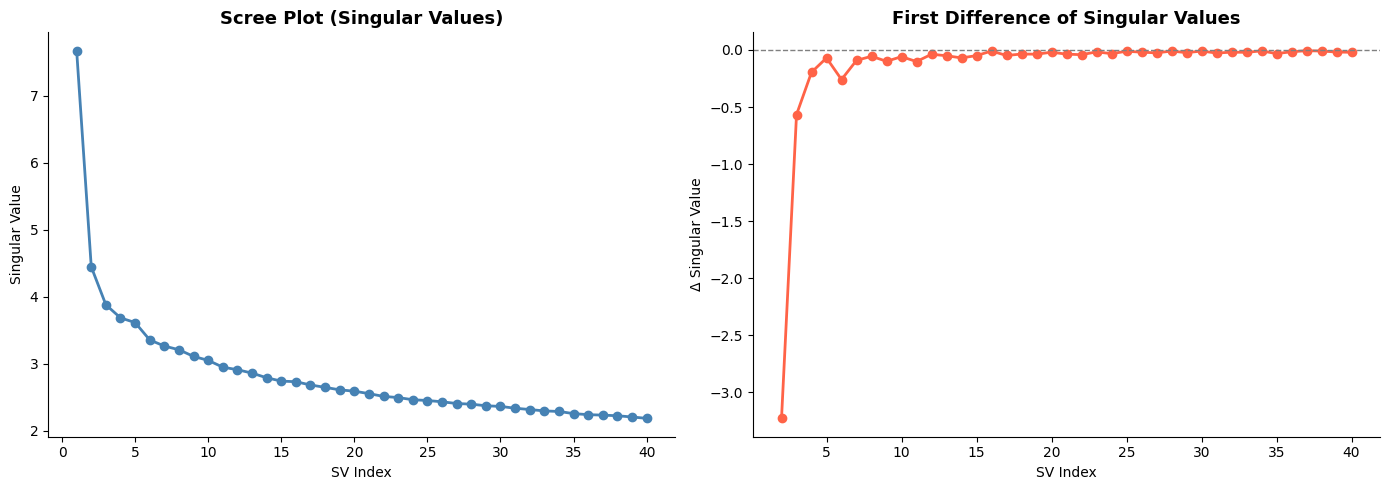


Scree Insight:
  The elbow in the first-difference plot marks where marginal information
  gain from additional SVs diminishes rapidly — a natural cut-point for
  dimensionality reduction beyond the 90%-variance threshold.


In [13]:
# ── Graph 4: Scree Plot ───────────────────────────────────────────────────────
fig4, axes4 = plot_scree(singular_values, n_show=40)
plt.show()

print("\nScree Insight:")
print("  The elbow in the first-difference plot marks where marginal information")
print("  gain from additional SVs diminishes rapidly — a natural cut-point for")
print("  dimensionality reduction beyond the 90%-variance threshold.")

In [14]:
# Truncate LSA to 90%-variance threshold
thresh = max(thresh, 2)
truncated_lsa = lsa_features[:, :thresh]
print(f"Truncated LSA shape: {truncated_lsa.shape}")
print(f"Using {thresh} latent semantic dimensions for clustering.")

Truncated LSA shape: (1517, 2)
Using 2 latent semantic dimensions for clustering.


## Clustering: K-Means + DBSCAN + Hierarchical Agglomerative

Three complementary clustering paradigms are applied to the LSA-reduced space:

| Method | Paradigm | Key strength |
|---|---|---|
| **K-Means** | Partition-based | Fast; identifies globular centroids |
| **DBSCAN** | Density-based | Detects arbitrary shapes; labels noise as -1 |
| **Agglomerative** | Hierarchical (representative) | Reveals nested cluster structure via dendrogram |

In [15]:
# Clustering semantic features
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters_km = kmeans.fit_predict(truncated_lsa)
df['cluster_kmeans'] = clusters_km
df.head()

print("K-Means cluster distribution:")
print(pd.Series(clusters_km).value_counts().sort_index())

K-Means cluster distribution:
0    254
1    304
2    385
3    210
4    364
Name: count, dtype: int64


  File "c:\Users\Me\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\joblib\externals\loky\backend\context.py", line 227, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(" "),
        capture_output=True)
  File "c:\Users\Me\AppData\Local\Python\pythoncore-3.14-64\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Me\AppData\Local\Python\pythoncore-3.14-64\Lib\subprocess.py", line 1038, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^

### DBSCAN — Density-Based Spatial Clustering

DBSCAN groups points that are tightly packed together and marks low-density points as noise
(label = -1). Unlike K-Means it does **not** require specifying k in advance.
The `eps` (neighbourhood radius) is estimated from the k-NN distance plot.

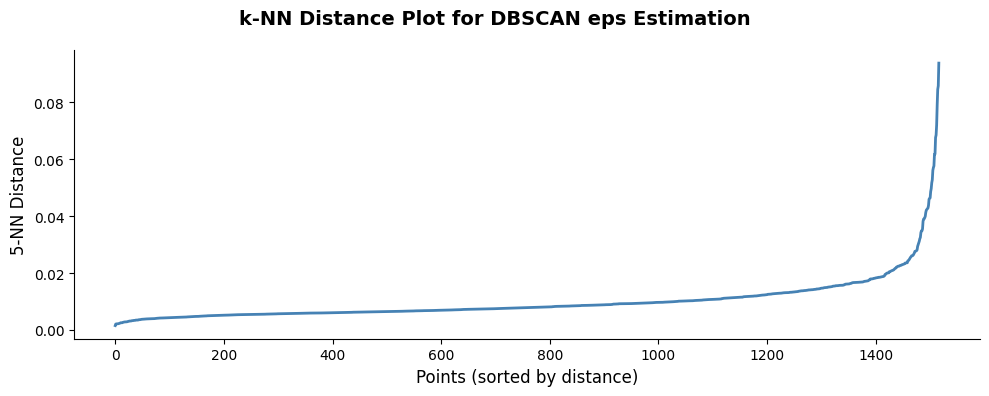

Estimated eps (5th percentile of 5-NN distances): 0.0041


In [16]:
# ── DBSCAN: Estimate eps via k-NN distance plot ───────────────────────────────

k = 5
nbrs = NearestNeighbors(n_neighbors=k, algorithm='ball_tree').fit(truncated_lsa)
distances, _ = nbrs.kneighbors(truncated_lsa)
knn_dists = np.sort(distances[:, k-1])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(knn_dists, lw=2, color='steelblue')
ax.set_xlabel('Points (sorted by distance)', fontsize=12)
ax.set_ylabel(f'{k}-NN Distance', fontsize=12)
ax.spines[['top', 'right']].set_visible(False)
fig.suptitle('k-NN Distance Plot for DBSCAN eps Estimation', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

# Use the "elbow" value — 95th percentile of distances as eps estimate
eps_est = float(np.percentile(knn_dists, 5))
print(f"Estimated eps (5th percentile of {k}-NN distances): {eps_est:.4f}")

In [17]:
# ── Run DBSCAN ───────────────────────────────────────────────────────────────
dbscan = DBSCAN(eps=eps_est, min_samples=5, metric='euclidean', n_jobs=-1)
clusters_db = dbscan.fit_predict(truncated_lsa)
df['cluster_dbscan'] = clusters_db

n_clusters_db = len(set(clusters_db)) - (1 if -1 in clusters_db else 0)
n_noise_db    = (clusters_db == -1).sum()

print(f"DBSCAN found {n_clusters_db} cluster(s) + {n_noise_db} noise points")
print("Cluster distribution (−1 = noise):")
print(pd.Series(clusters_db).value_counts().sort_index())

DBSCAN found 22 cluster(s) + 1360 noise points
Cluster distribution (−1 = noise):
-1     1360
 0        7
 1       17
 2        9
 3        5
 4       11
 5        5
 6        7
 7        6
 8        6
 9        8
 10       7
 11       6
 12       5
 13       6
 14       9
 15      10
 16       5
 17       5
 18       7
 19       5
 20       5
 21       6
Name: count, dtype: int64


### Hierarchical Agglomerative Clustering (HAC)

HAC merges the two closest clusters at each step using **Ward linkage** (minimises
within-cluster variance). The resulting dendrogram gives a multi-resolution view of the
cluster structure — useful for choosing the number of clusters without pre-specifying k.

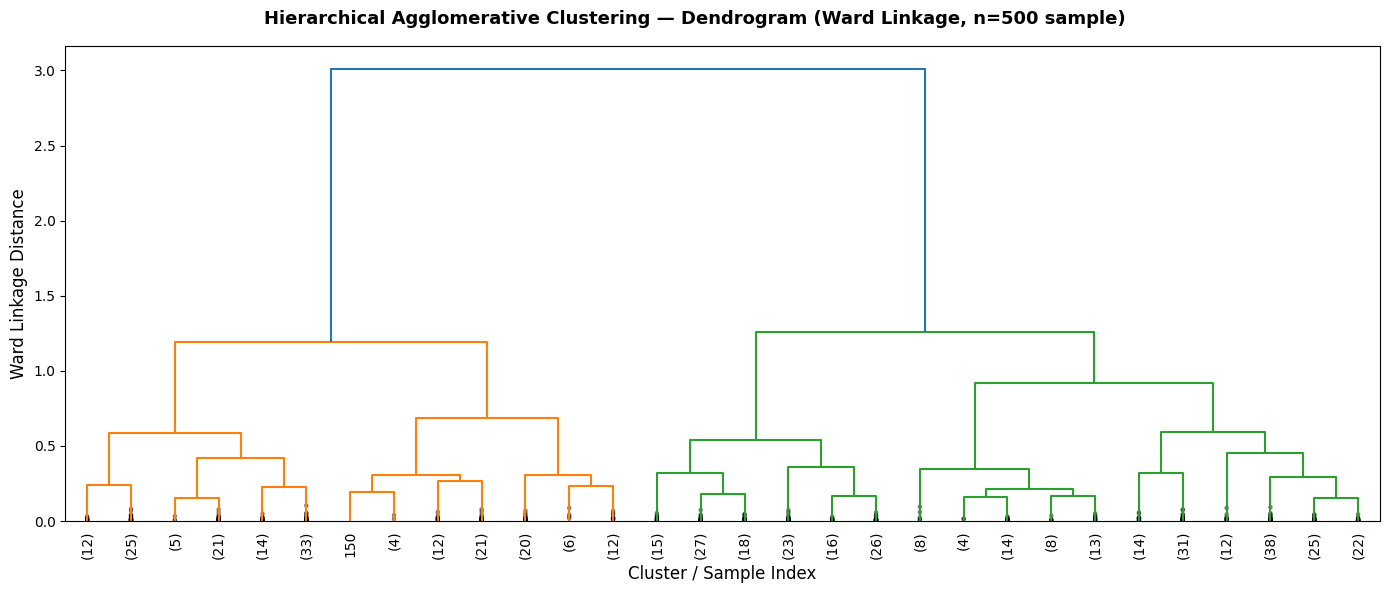

HAC cluster distribution (sample, 5 clusters):
1    110
2     76
3    125
4     47
5    142
Name: count, dtype: int64


In [18]:
# ── Hierarchical Agglomerative Clustering ────────────────────────────────────
# Subsample for dendrogram readability (linkage on full dataset is expensive)
np.random.seed(42)
sample_idx  = np.random.choice(len(truncated_lsa), size=min(500, len(truncated_lsa)), replace=False)
sample_lsa  = truncated_lsa[sample_idx]

Z = linkage(sample_lsa, method='ward', metric='euclidean')

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z, ax=ax, truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=10, show_contracted=True)
ax.set_xlabel('Cluster / Sample Index', fontsize=12)
ax.set_ylabel('Ward Linkage Distance', fontsize=12)
fig.suptitle('Hierarchical Agglomerative Clustering — Dendrogram (Ward Linkage, n=500 sample)',
             fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

# Cut dendrogram at 5 clusters to match K-Means for comparability
hac_labels_sample = fcluster(Z, t=5, criterion='maxclust')
print(f"HAC cluster distribution (sample, 5 clusters):")
print(pd.Series(hac_labels_sample).value_counts().sort_index())

In [19]:
# Apply HAC to full dataset via linkage on full matrix
Z_full = linkage(truncated_lsa, method='ward', metric='euclidean')
clusters_hac = fcluster(Z_full, t=5, criterion='maxclust') - 1  # 0-indexed
df['cluster_hac'] = clusters_hac

print("HAC full-dataset cluster distribution:")
print(pd.Series(clusters_hac).value_counts().sort_index())

HAC full-dataset cluster distribution:
0    490
1    127
2    247
3    201
4    452
Name: count, dtype: int64


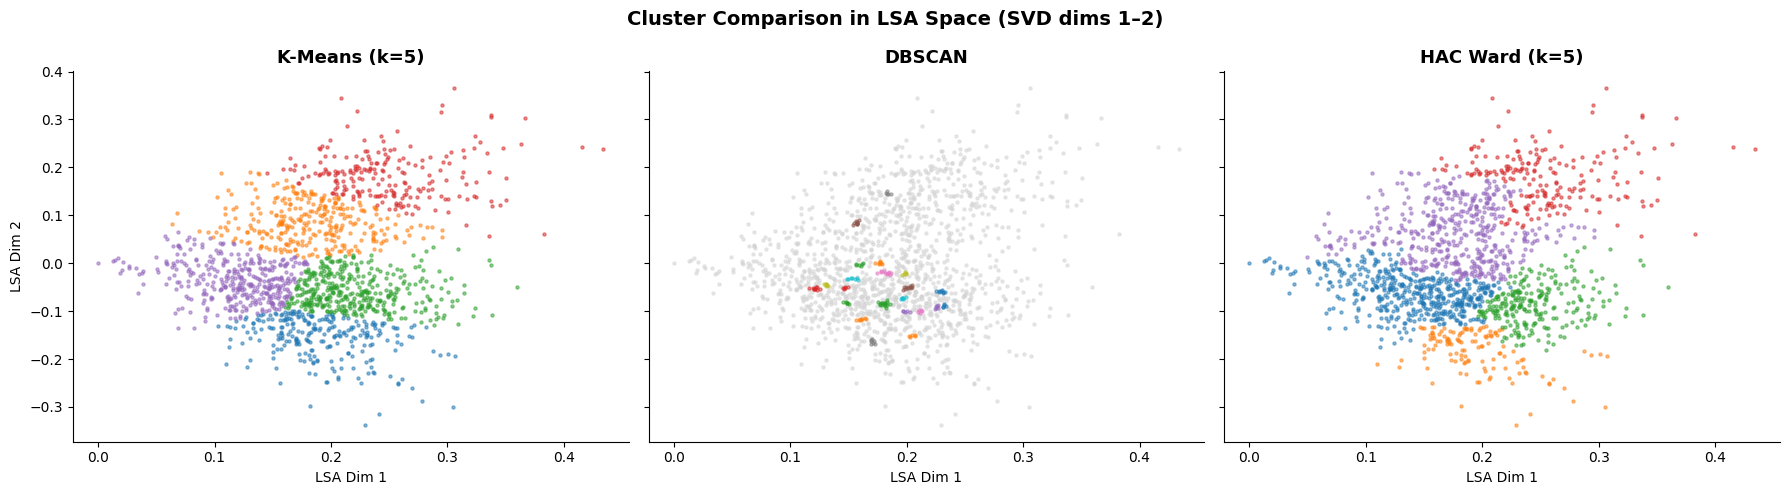

Clustering Observations:
  K-Means:       Produces balanced, globular clusters; sensitive to initialisation.
  DBSCAN:        Identifies dense review neighbourhoods; noise points may be outlier reviews.
  HAC (Ward):    Reveals hierarchical topic structure; most stable for nested themes.


In [20]:
# ── 2-D projection (SVD dim 0 vs dim 1) coloured by each method ───────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)
palette = sns.color_palette('tab10', 10)

for ax, (labels, title) in zip(axes, [
    (clusters_km,  'K-Means (k=5)'),
    (clusters_db,  'DBSCAN'),
    (clusters_hac, 'HAC Ward (k=5)'),
]):
    unique = sorted(set(labels))
    for i, lbl in enumerate(unique):
        mask = labels == lbl
        color = 'lightgray' if lbl == -1 else palette[i % 10]
        lname = 'Noise' if lbl == -1 else f'Cluster {lbl}'
        ax.scatter(truncated_lsa[mask, 0], truncated_lsa[mask, 1],
                   color=color, s=5, alpha=0.5, label=lname)
    ax.set_title(title, fontsize=13, weight='bold')
    ax.set_xlabel('LSA Dim 1')
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_ylabel('LSA Dim 2')
plt.suptitle('Cluster Comparison in LSA Space (SVD dims 1–2)', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

print("Clustering Observations:")
print("  K-Means:       Produces balanced, globular clusters; sensitive to initialisation.")
print("  DBSCAN:        Identifies dense review neighbourhoods; noise points may be outlier reviews.")
print("  HAC (Ward):    Reveals hierarchical topic structure; most stable for nested themes.")

## Final Dataset: Fully Numerical, ML-Ready

The final feature table is assembled from:
- **LSA features** (truncated SVD dimensions) — semantic representation of review text
- **Encoded structured features** — rating, date parts, location frequency, text lengths
- **Cluster labels** — from K-Means, DBSCAN, and HAC
- **Target** — `is_helpful` (binary)

`helpful_votes` is **excluded as a feature** (data leakage guard) but remains in `df` for auditing.

In [21]:
# ── Build final ML-ready feature DataFrame ───────────────────────────────────

# LSA columns
lsa_cols = [f'lsa_{i}' for i in range(truncated_lsa.shape[1])]
df_lsa = pd.DataFrame(truncated_lsa, columns=lsa_cols, index=df.index)

# Structured numerical features (NO helpful_votes — data leakage)
structured_features = ['rating', 'year', 'month', 'day_of_week',
                       'location_freq', 'title_len', 'body_len', 'word_count']

# Add verified_purchase if present
if 'verified_purchase' in df.columns:
    structured_features.append('verified_purchase')

df_structured = df[structured_features].copy()

# Cluster labels
df_clusters = df[['cluster_kmeans', 'cluster_dbscan', 'cluster_hac']].copy()

# Target
df_target = df[['is_helpful']].copy()

# Concatenate everything
df_final = pd.concat([df_lsa, df_structured, df_clusters, df_target], axis=1)

print(f"Final dataset shape: {df_final.shape}")
print(f"\nAll dtypes numerical? {all(df_final.dtypes.apply(lambda x: np.issubdtype(x, np.number)))}")
print(f"\nColumn list ({len(df_final.columns)} columns):")
print(list(df_final.columns[:10]), '...')
print("\nSample:")
df_final.head()

Final dataset shape: (1517, 14)

All dtypes numerical? True

Column list (14 columns):
['lsa_0', 'lsa_1', 'rating', 'year', 'month', 'day_of_week', 'location_freq', 'title_len', 'body_len', 'word_count'] ...

Sample:


,lsa_0,lsa_1,rating,year,month,day_of_week,location_freq,title_len,body_len,word_count,cluster_kmeans,cluster_dbscan,cluster_hac,is_helpful
0,0.261910,-0.091982,5,2026,3,1,1190,31,557,61,2,-1,2,1
1,0.214216,0.025695,5,2026,4,5,1190,23,495,43,1,-1,4,1
2,0.219601,-0.071909,5,2026,4,4,1190,56,1369,135,2,-1,2,1
3,0.280363,-0.098673,5,2026,3,1,1190,31,935,82,2,-1,2,1
4,0.176712,-0.035696,5,2026,4,5,1190,51,132,20,2,-1,4,0


In [22]:
# Sanity check: zero categorical columns remain
cat_cols = df_final.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Remaining categorical columns: {cat_cols if cat_cols else 'None — all numerical ✓'}")
print("\nMissing values per column (top offenders):")
missing = df_final.isnull().sum()
print(missing[missing > 0] if missing.any() else "  None ✓")

# Fill any edge-case NaNs
df_final = df_final.fillna(0)
print("\nFinal shape after NaN fill:", df_final.shape)

Remaining categorical columns: None — all numerical ✓

Missing values per column (top offenders):
  None ✓

Final shape after NaN fill: (1517, 14)


In [23]:
# ── Export final dataset ─────────────────────────────────────────────────────
# Full df (with helpful_votes and text columns) for reference
df.to_csv("data/amazon_bestsellers_reviews_cleaned_clustered.csv", index=False)

# ML-ready numerical dataset (helpful_votes excluded)
df_final.to_csv("data/amazon_bestsellers_reviews_ml_ready.csv", index=False)

print("Exported:")
print("  • data/amazon_bestsellers_reviews_cleaned_clustered.csv  — full reference dataset")
print("  • data/amazon_bestsellers_reviews_ml_ready.csv           — ML-ready (all numerical, no leakage)")

Exported:
  • data/amazon_bestsellers_reviews_cleaned_clustered.csv  — full reference dataset
  • data/amazon_bestsellers_reviews_ml_ready.csv           — ML-ready (all numerical, no leakage)
